  KNN HYPERPARAMETER TUNING — CIC IoT 2023 (Real Data)
  Save folder: D:\Syllabus\MCA\Practical\SEM 4\AIML\ciciot\knn_saved

[✓] Dataset already saved — loading from file (fast!)
    Train : 39,998  |  Test : 10,000  |  Classes : 34

─────────────────────────────────────────────────────────────────
  [1] RANDOM SEARCH
─────────────────────────────────────────────────────────────────
    Iter   1/40 | Score: 0.6494 | Best: 0.6494
    Iter   2/40 | Score: 0.5759 | Best: 0.6494
    Iter   3/40 | Score: 0.6312 | Best: 0.6494
    Iter   4/40 | Score: 0.6335 | Best: 0.6494
    Iter   5/40 | Score: 0.6257 | Best: 0.6494
    Iter   6/40 | Score: 0.6146 | Best: 0.6494
    Iter   7/40 | Score: 0.6269 | Best: 0.6494
    Iter   8/40 | Score: 0.6549 | Best: 0.6549
    Iter   9/40 | Score: 0.6501 | Best: 0.6549
    Iter  10/40 | Score: 0.5931 | Best: 0.6549
    Iter  11/40 | Score: 0.6133 | Best: 0.6549
    Iter  12/40 | Score: 0.6549 | Best: 0.6549
    Iter  13/40 | Score: 0.6448 | Best: 0.6549
   

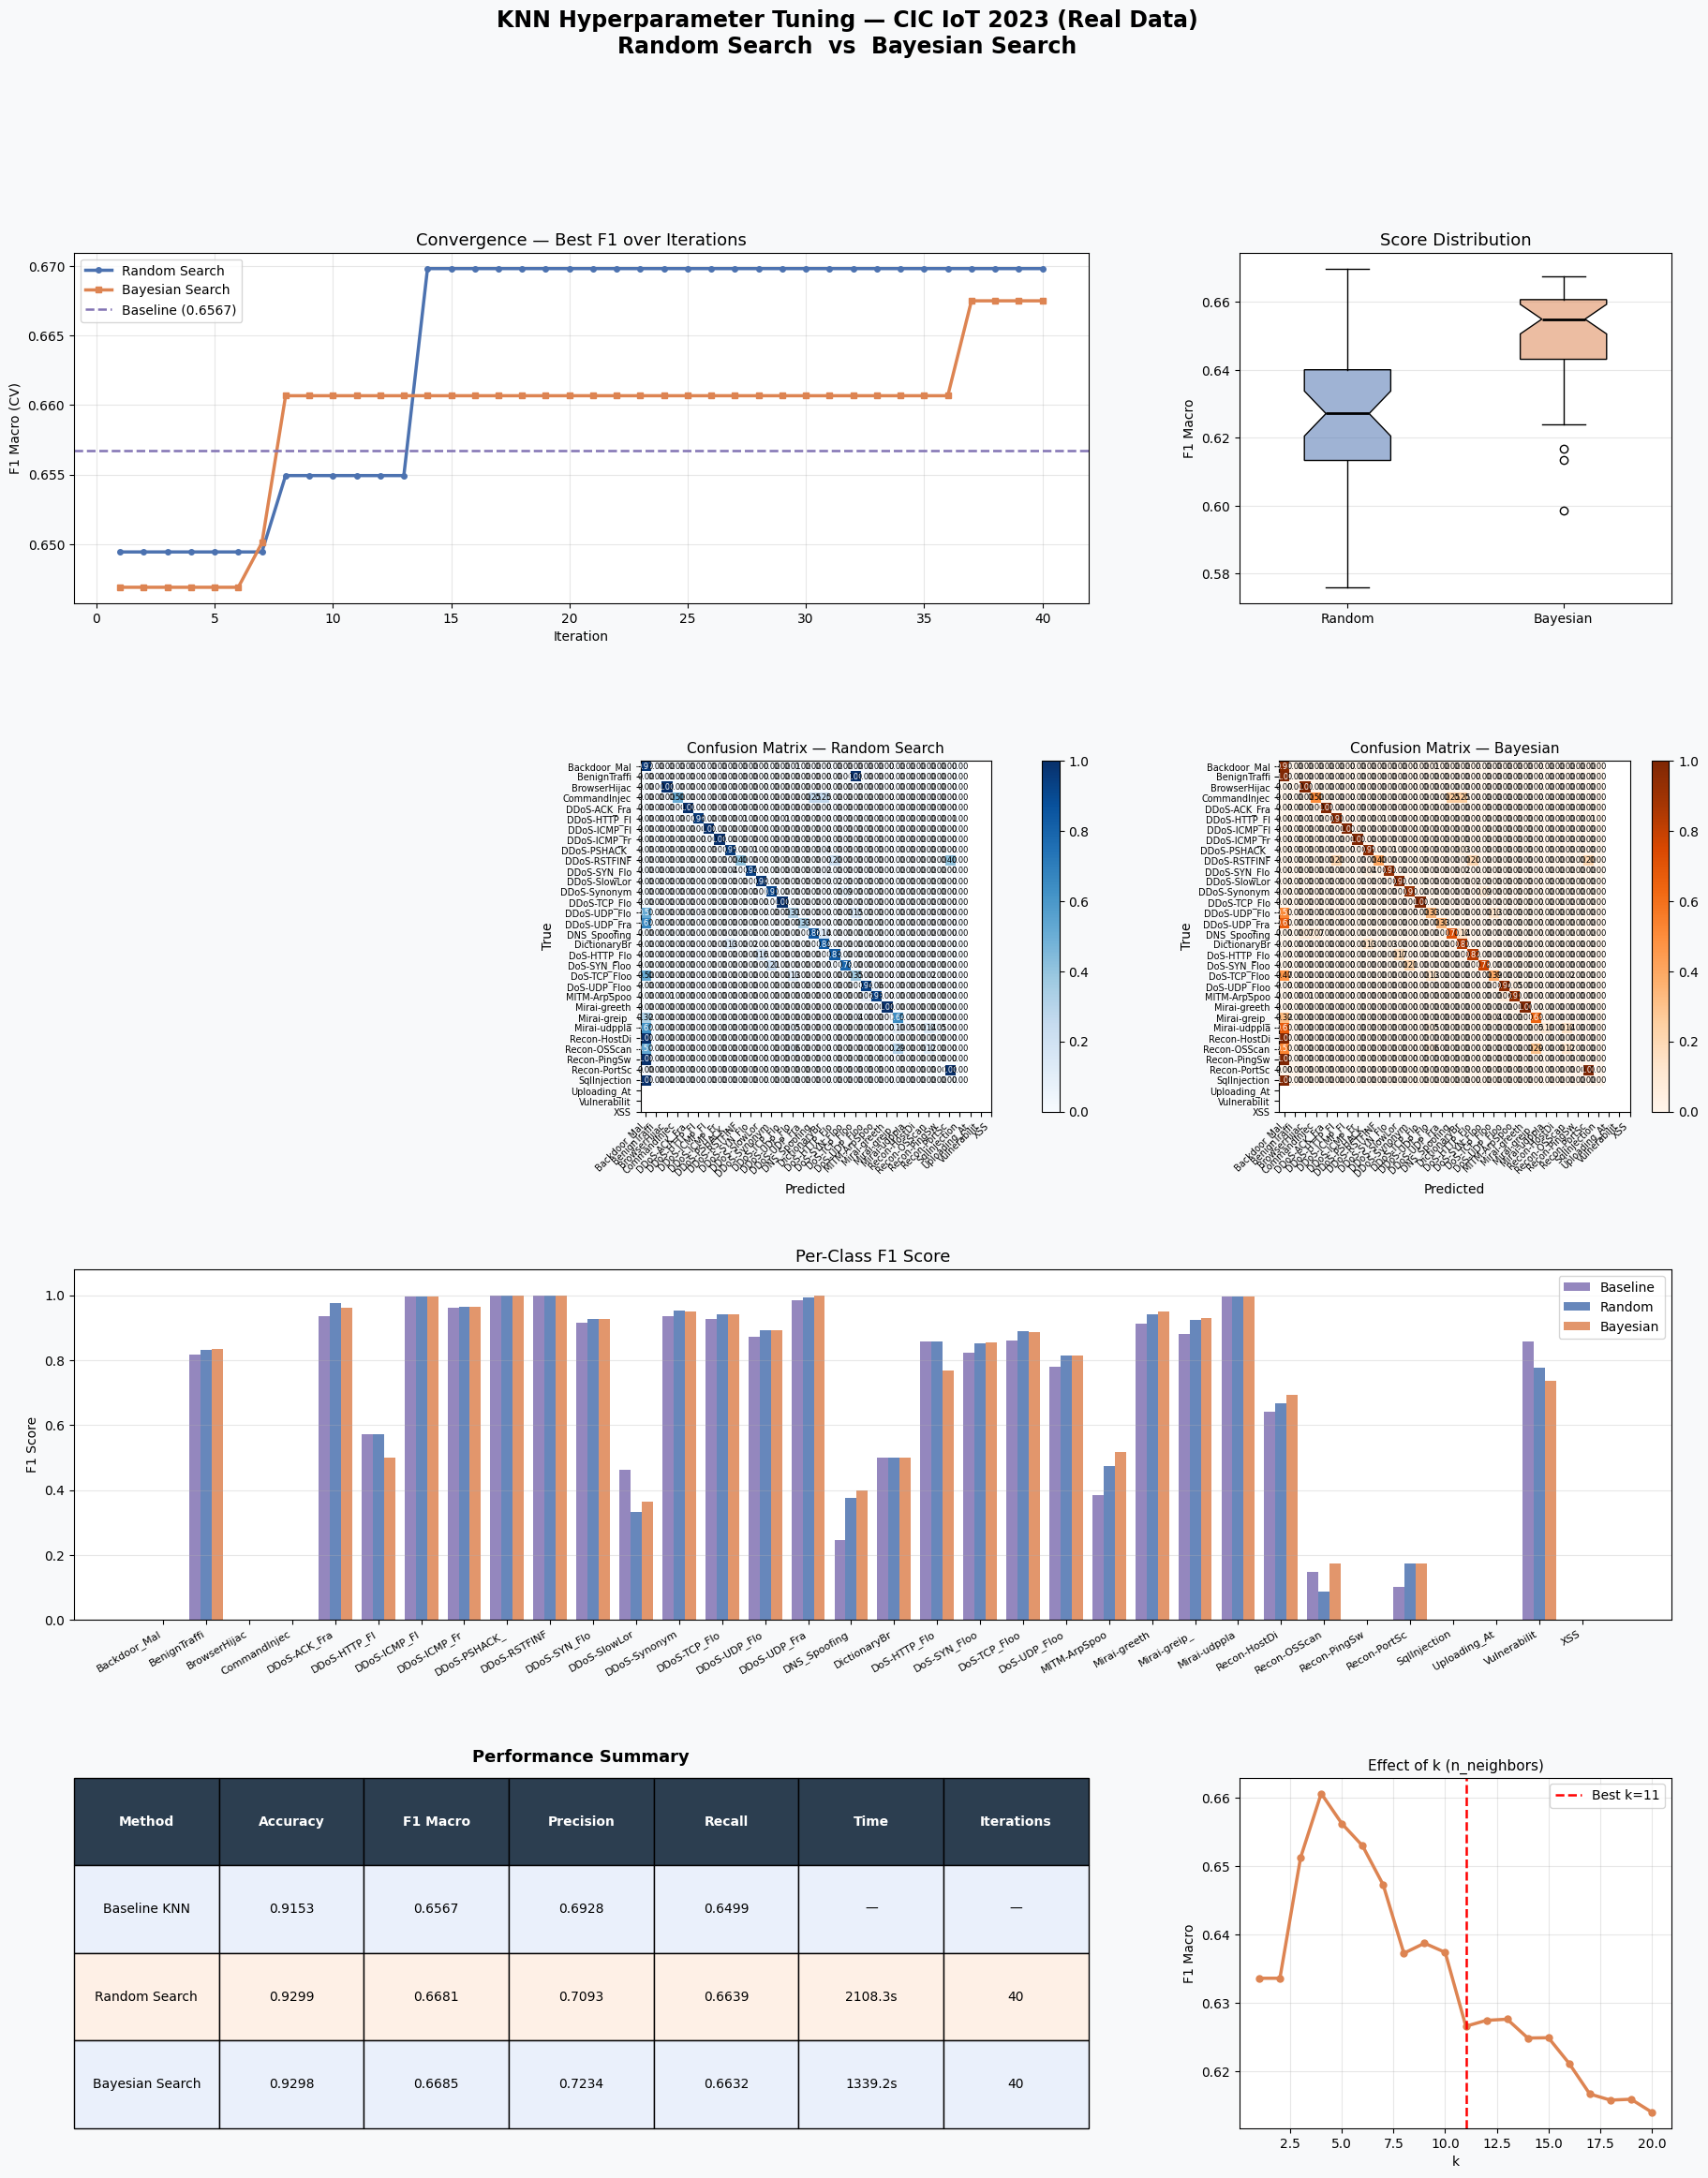


[✓] Chart saved → D:\Syllabus\MCA\Practical\SEM 4\AIML\ciciot\knn_saved\knn_results.png

  FINAL SUMMARY
  Method                   Accuracy   F1 Macro       Time
  ────────────────────── ────────── ────────── ──────────
  Baseline KNN               0.9153     0.6567          —
  Random Search              0.9299     0.6681    2108.3s
  Bayesian Search            0.9298     0.6685    1339.2s

  Best Random   params : {'n_neighbors': 10, 'weights': 'distance', 'metric': 'manhattan', 'algorithm': 'auto', 'leaf_size': 13, 'p': 2}
  Best Bayesian params : {'n_neighbors': 11, 'weights': 'distance', 'metric': 'minkowski', 'algorithm': 'auto', 'leaf_size': 12, 'p': 1}

  [✓] All models saved in: D:\Syllabus\MCA\Practical\SEM 4\AIML\ciciot\knn_saved

[✓] Done!


In [1]:
"""
KNN Hyperparameter Tuning: Random Search vs Bayesian Search
Dataset: CIC IoT 2023 — REAL DATA (multiple CSV files)
✅ FIXES APPLIED:
   - Memory-safe loading (nrows=1000 per file)
   - Rare class removal (fixes ValueError)
   - Model saving with joblib (train once, load forever!)
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import time
import joblib
from collections import Counter

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm

warnings.filterwarnings("ignore")
np.random.seed(42)

# ─────────────────────────────────────────────────────────────
# ✅ SETTINGS — CHANGE THESE
# ─────────────────────────────────────────────────────────────

CSV_FOLDER   = r"D:\Syllabus\MCA\Practical\SEM 4\AIML\ciciot"   # <-- YOUR FOLDER
LABEL_COLUMN = "label"    # <-- your label column name
ROWS_PER_FILE = 1000      # rows per CSV file (safe for 16GB RAM)
MAX_ROWS      = 50000     # max total rows after combining
SAVE_DIR      = r"D:\Syllabus\MCA\Practical\SEM 4\AIML\ciciot\knn_saved"  # <-- SAVE FOLDER

# ─────────────────────────────────────────────────────────────
# CREATE SAVE FOLDER
# ─────────────────────────────────────────────────────────────
os.makedirs(SAVE_DIR, exist_ok=True)

# Save file paths
PATH_DATASET       = os.path.join(SAVE_DIR, "dataset.npz")
PATH_SCALER        = os.path.join(SAVE_DIR, "scaler.pkl")
PATH_ENCODER       = os.path.join(SAVE_DIR, "label_encoder.pkl")
PATH_RAND_MODEL    = os.path.join(SAVE_DIR, "model_random.pkl")
PATH_BAYES_MODEL   = os.path.join(SAVE_DIR, "model_bayesian.pkl")
PATH_RAND_RESULTS  = os.path.join(SAVE_DIR, "random_results.pkl")
PATH_BAYES_RESULTS = os.path.join(SAVE_DIR, "bayesian_results.pkl")

print("=" * 65)
print("  KNN HYPERPARAMETER TUNING — CIC IoT 2023 (Real Data)")
print(f"  Save folder: {SAVE_DIR}")
print("=" * 65)

# ─────────────────────────────────────────────────────────────
# STEP 1 — LOAD DATASET (skip if already saved)
# ─────────────────────────────────────────────────────────────
if os.path.exists(PATH_DATASET):
    print("\n[✓] Dataset already saved — loading from file (fast!)")
    data    = np.load(PATH_DATASET, allow_pickle=True)
    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train"]
    y_test  = data["y_test"]
    scaler  = joblib.load(PATH_SCALER)
    le      = joblib.load(PATH_ENCODER)
    print(f"    Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}  |  Classes : {len(le.classes_)}")

else:
    print("\n[*] First run — loading CSV files ...")
    csv_files = glob.glob(os.path.join(CSV_FOLDER, "*.csv"))

    if len(csv_files) == 0:
        raise FileNotFoundError(
            f"\n❌ No CSV files found in: {CSV_FOLDER}\n"
            f"   Please update CSV_FOLDER at the top of this script."
        )

    print(f"\n[*] Found {len(csv_files)} CSV file(s):")
    for f in csv_files:
        print(f"    • {os.path.basename(f)}")

    print(f"\n[*] Loading {ROWS_PER_FILE} rows per file ...")
    dfs = []
    for f in csv_files:
        try:
            df_tmp = pd.read_csv(f, nrows=ROWS_PER_FILE, low_memory=False)
            dfs.append(df_tmp)
            print(f"    ✓ {os.path.basename(f):40s} → {df_tmp.shape[0]:>7,} rows, {df_tmp.shape[1]} cols")
        except Exception as e:
            print(f"    ✗ {os.path.basename(f)} — ERROR: {e}")

    df = pd.concat(dfs, ignore_index=True)
    print(f"\n[*] Combined shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    # Auto-detect label column
    if LABEL_COLUMN not in df.columns:
        candidates = [c for c in df.columns if c.lower() in ("label", "attack", "class", "category", "target")]
        if candidates:
            LABEL_COLUMN = candidates[0]
            print(f"[!] Auto-detected label column: '{LABEL_COLUMN}'")
        else:
            print(f"\n❌ Could not find label column. Available columns:\n{list(df.columns)}")
            raise ValueError("Please set LABEL_COLUMN manually at the top of the script.")

    print(f"[*] Label column : '{LABEL_COLUMN}'")
    print(f"[*] Classes found:\n    {df[LABEL_COLUMN].value_counts().to_dict()}")

    # ── Preprocessing ──────────────────────────────────────
    df    = df.dropna(subset=[LABEL_COLUMN])
    y_raw = df[LABEL_COLUMN].astype(str)
    X_raw = df.drop(columns=[LABEL_COLUMN])
    X_raw = X_raw.select_dtypes(include=[np.number])
    print(f"[*] Numeric features used: {X_raw.shape[1]}")
    X_raw = X_raw.dropna(axis=1, how="all")
    X_raw = X_raw.loc[:, X_raw.nunique() > 1]
    X_raw = X_raw.fillna(X_raw.median())
    X_raw = X_raw.replace([np.inf, -np.inf], np.nan).fillna(0)

    X     = X_raw.values
    y_str = y_raw.values

    # Sample down if needed
    if MAX_ROWS and len(X) > MAX_ROWS:
        idx   = np.random.choice(len(X), MAX_ROWS, replace=False)
        X, y_str = X[idx], y_str[idx]
        print(f"[*] Sampled down to {MAX_ROWS:,} rows")

    # Encode labels
    le = LabelEncoder()
    y  = le.fit_transform(y_str)

    # ✅ FIX: Remove classes with fewer than 2 samples
    counts    = Counter(y)
    valid_idx = np.array([i for i, label in enumerate(y) if counts[label] >= 2])
    X, y      = X[valid_idx], y[valid_idx]
    print(f"[*] After removing rare classes: {len(X):,} samples, {len(np.unique(y))} classes")

    print(f"[*] Final dataset : {X.shape[0]:,} samples × {X.shape[1]} features")
    print(f"[*] Classes       : {len(le.classes_)}")

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"[*] Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

    # ✅ SAVE dataset + scaler + encoder
    np.savez(PATH_DATASET, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
    joblib.dump(scaler, PATH_SCALER)
    joblib.dump(le,     PATH_ENCODER)
    print(f"[✓] Dataset saved → {SAVE_DIR}")

# ─────────────────────────────────────────────────────────────
# STEP 2 — RANDOM SEARCH (skip if already saved)
# ─────────────────────────────────────────────────────────────
CV    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORE = "f1_macro"
rng   = np.random.default_rng(42)

def evaluate_params(params):
    knn    = KNeighborsClassifier(**params)
    scores = cross_val_score(knn, X_train, y_train, cv=CV, scoring=SCORE, n_jobs=-1)
    return scores.mean()

if os.path.exists(PATH_RAND_MODEL) and os.path.exists(PATH_RAND_RESULTS):
    print("\n[✓] Random Search already done — loading saved results ...")
    rand_data      = joblib.load(PATH_RAND_RESULTS)
    random_results = rand_data["scores"]
    random_params  = rand_data["params"]
    best_rand_par  = rand_data["best_params"]
    best_rand_sc   = rand_data["best_score"]
    random_time    = rand_data["time"]
    knn_rand       = joblib.load(PATH_RAND_MODEL)
    print(f"    Best F1 : {best_rand_sc:.4f}  |  Params : {best_rand_par}")

else:
    print("\n" + "─" * 65)
    print("  [1] RANDOM SEARCH")
    print("─" * 65)

    N_RANDOM_ITER = 40
    random_results, random_params = [], []

    t0 = time.time()
    for i in range(N_RANDOM_ITER):
        params = {
            "n_neighbors" : int(rng.integers(1, 31)),
            "weights"     : str(rng.choice(["uniform", "distance"])),
            "metric"      : str(rng.choice(["euclidean", "manhattan", "chebyshev", "minkowski"])),
            "algorithm"   : "auto",
            "leaf_size"   : int(rng.integers(10, 51)),
            "p"           : int(rng.integers(1, 4)),
        }
        score = evaluate_params(params)
        random_results.append(score)
        random_params.append(params)
        print(f"    Iter {i+1:3d}/{N_RANDOM_ITER} | Score: {score:.4f} | Best: {max(random_results):.4f}")

    random_time   = time.time() - t0
    best_rand_idx = int(np.argmax(random_results))
    best_rand_par = random_params[best_rand_idx]
    best_rand_sc  = random_results[best_rand_idx]
    print(f"\n  ✓ Best F1: {best_rand_sc:.4f}  |  Time: {random_time:.1f}s")
    print(f"  ✓ Params: {best_rand_par}")

    # ✅ SAVE Random Search
    knn_rand = KNeighborsClassifier(**best_rand_par)
    knn_rand.fit(X_train, y_train)
    joblib.dump(knn_rand, PATH_RAND_MODEL)
    joblib.dump({
        "scores"      : random_results,
        "params"      : random_params,
        "best_params" : best_rand_par,
        "best_score"  : best_rand_sc,
        "time"        : random_time
    }, PATH_RAND_RESULTS)
    print(f"  [✓] Random Search model saved → {PATH_RAND_MODEL}")

# ─────────────────────────────────────────────────────────────
# STEP 3 — BAYESIAN SEARCH (skip if already saved)
# ─────────────────────────────────────────────────────────────
WEIGHTS_MAP = {"uniform": 0, "distance": 1}
METRIC_MAP  = {"euclidean": 0, "manhattan": 1, "chebyshev": 2, "minkowski": 3}

def decode(x):
    return {
        "n_neighbors": max(1, min(30, int(round(x[0]*30)))),
        "weights"    : "distance" if x[1] > 0.5 else "uniform",
        "metric"     : ["euclidean","manhattan","chebyshev","minkowski"][max(0,min(3,int(round(x[2]*3))))],
        "algorithm"  : "auto",
        "leaf_size"  : max(10, min(50, int(round(x[3]*40+10)))),
        "p"          : max(1, min(3, int(round(x[4]*2+1)))),
    }

def ei_acquisition(X_new, X_obs, y_obs, gp, xi=0.01):
    mu, sigma = gp.predict(X_new, return_std=True)
    best = np.max(y_obs)
    Z    = (mu - best - xi) / (sigma + 1e-9)
    ei   = (mu - best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-10] = 0.0
    return ei

if os.path.exists(PATH_BAYES_MODEL) and os.path.exists(PATH_BAYES_RESULTS):
    print("\n[✓] Bayesian Search already done — loading saved results ...")
    bayes_data    = joblib.load(PATH_BAYES_RESULTS)
    bayes_results = bayes_data["scores"]
    best_bay_par  = bayes_data["best_params"]
    best_bay_sc   = bayes_data["best_score"]
    bayes_time    = bayes_data["time"]
    knn_bayes     = joblib.load(PATH_BAYES_MODEL)
    print(f"    Best F1 : {best_bay_sc:.4f}  |  Params : {best_bay_par}")

else:
    print("\n" + "─" * 65)
    print("  [2] BAYESIAN SEARCH  (Gaussian Process + EI)")
    print("─" * 65)

    N_INIT, N_BO = 8, 32
    bayes_X, bayes_y, bayes_params_list = [], [], []

    t0 = time.time()
    for _ in range(N_INIT):
        x = rng.uniform(0, 1, 5)
        x[1] = round(x[1]); x[2] = round(x[2]*3)/3; x[4] = round(x[4]*2)/2
        p  = decode(x); sc = evaluate_params(p)
        bayes_X.append(x); bayes_y.append(sc); bayes_params_list.append(p)

    gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), alpha=1e-6, normalize_y=True, n_restarts_optimizer=3)
    bayes_results = list(bayes_y)

    for i in range(N_BO):
        gp.fit(np.array(bayes_X), np.array(bayes_y))
        cands = rng.uniform(0, 1, (2000, 5))
        cands[:,1] = np.round(cands[:,1]); cands[:,2] = np.round(cands[:,2]*3)/3; cands[:,4] = np.round(cands[:,4]*2)/2
        best_c = cands[np.argmax(ei_acquisition(cands, np.array(bayes_X), np.array(bayes_y), gp))]
        p = decode(best_c); sc = evaluate_params(p)
        bayes_X.append(best_c); bayes_y.append(sc)
        bayes_results.append(sc); bayes_params_list.append(p)
        print(f"    Iter {i+1:3d}/{N_BO} | Score: {sc:.4f} | Best: {max(bayes_results):.4f}")

    bayes_time   = time.time() - t0
    best_bay_idx = int(np.argmax(bayes_results))
    best_bay_par = bayes_params_list[best_bay_idx]
    best_bay_sc  = bayes_results[best_bay_idx]
    print(f"\n  ✓ Best F1: {best_bay_sc:.4f}  |  Time: {bayes_time:.1f}s")
    print(f"  ✓ Params: {best_bay_par}")

    # ✅ SAVE Bayesian Search
    knn_bayes = KNeighborsClassifier(**best_bay_par)
    knn_bayes.fit(X_train, y_train)
    joblib.dump(knn_bayes, PATH_BAYES_MODEL)
    joblib.dump({
        "scores"      : bayes_results,
        "best_params" : best_bay_par,
        "best_score"  : best_bay_sc,
        "time"        : bayes_time
    }, PATH_BAYES_RESULTS)
    print(f"  [✓] Bayesian Search model saved → {PATH_BAYES_MODEL}")

# ─────────────────────────────────────────────────────────────
# STEP 4 — FINAL EVALUATION ON TEST SET
# ─────────────────────────────────────────────────────────────
print("\n" + "─" * 65)
print("  [3] FINAL EVALUATION ON TEST SET")
print("─" * 65)

def eval_test(knn_model, label):
    yp = knn_model.predict(X_test)
    a  = accuracy_score(y_test, yp)
    f  = f1_score(y_test, yp, average="macro", zero_division=0)
    p  = precision_score(y_test, yp, average="macro", zero_division=0)
    r  = recall_score(y_test, yp, average="macro", zero_division=0)
    print(f"\n  [{label}]  Acc={a:.4f}  F1={f:.4f}  Prec={p:.4f}  Rec={r:.4f}")
    return yp, a, f, p, r

knn_base = KNeighborsClassifier()
knn_base.fit(X_train, y_train)
yp_base  = knn_base.predict(X_test)
a0 = accuracy_score(y_test, yp_base)
f0 = f1_score(y_test, yp_base, average="macro", zero_division=0)
p0 = precision_score(y_test, yp_base, average="macro", zero_division=0)
r0 = recall_score(y_test, yp_base, average="macro", zero_division=0)
print(f"\n  [Baseline KNN]  Acc={a0:.4f}  F1={f0:.4f}  Prec={p0:.4f}  Rec={r0:.4f}")

yp_rand,  ar, fr, pr, rr = eval_test(knn_rand,  "Random Search Best")
yp_bayes, ab, fb, pb, rb = eval_test(knn_bayes, "Bayesian Search Best")

# ─────────────────────────────────────────────────────────────
# STEP 5 — PLOTS
# ─────────────────────────────────────────────────────────────
C1, C2, C3 = "#4C72B0", "#DD8452", "#8172B3"
fig = plt.figure(figsize=(22, 26), facecolor="#F8F9FA")
fig.suptitle("KNN Hyperparameter Tuning — CIC IoT 2023 (Real Data)\nRandom Search  vs  Bayesian Search",
             fontsize=17, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# Convergence
ax1 = fig.add_subplot(gs[0, :2])
rb_ = np.maximum.accumulate(random_results)
bb_ = np.maximum.accumulate(bayes_results)
ax1.plot(range(1, len(rb_)+1), rb_, color=C1, lw=2.5, marker="o", ms=4, label="Random Search")
ax1.plot(range(1, len(bb_)+1), bb_, color=C2, lw=2.5, marker="s", ms=4, label="Bayesian Search")
ax1.axhline(f0, color=C3, ls="--", lw=1.8, label=f"Baseline ({f0:.4f})")
ax1.set_title("Convergence — Best F1 over Iterations", fontsize=13)
ax1.set_xlabel("Iteration"); ax1.set_ylabel("F1 Macro (CV)")
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_facecolor("white")

# Boxplot
ax2 = fig.add_subplot(gs[0, 2])
bp = ax2.boxplot([random_results, bayes_results], labels=["Random", "Bayesian"],
                  patch_artist=True, notch=True, widths=0.4)
bp["boxes"][0].set_facecolor(C1+"88"); bp["boxes"][1].set_facecolor(C2+"88")
for m in bp["medians"]: m.set(color="black", linewidth=2)
ax2.set_title("Score Distribution", fontsize=13)
ax2.set_ylabel("F1 Macro"); ax2.grid(alpha=0.3, axis="y"); ax2.set_facecolor("white")

# Confusion matrices
short = [c[:12] for c in le.classes_]
for ax_gs, yp, title, cmap in [
    (gs[1, :2], yp_rand,  "Confusion Matrix — Random Search", "Blues"),
    (gs[1, 2],  yp_bayes, "Confusion Matrix — Bayesian",      "Oranges"),
]:
    ax  = fig.add_subplot(ax_gs)
    cm  = confusion_matrix(y_test, yp).astype(float)
    cm_n = cm / cm.sum(axis=1, keepdims=True)
    im  = ax.imshow(cm_n, cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046)
    t   = np.arange(len(le.classes_))
    ax.set_xticks(t); ax.set_xticklabels(short, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(t); ax.set_yticklabels(short, fontsize=7)
    thresh = cm_n.max() / 2
    for i in range(cm_n.shape[0]):
        for j in range(cm_n.shape[1]):
            ax.text(j, i, f"{cm_n[i,j]:.2f}", ha="center", va="center",
                    color="white" if cm_n[i,j] > thresh else "black", fontsize=6)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

# Per-class F1
ax5 = fig.add_subplot(gs[2, :])
rpt_b = classification_report(y_test, yp_base,  output_dict=True, zero_division=0)
rpt_r = classification_report(y_test, yp_rand,  output_dict=True, zero_division=0)
rpt_y = classification_report(y_test, yp_bayes, output_dict=True, zero_division=0)
keys  = [str(i) for i in range(len(le.classes_))]
f_b   = [rpt_b.get(k,{}).get("f1-score",0) for k in keys]
f_r   = [rpt_r.get(k,{}).get("f1-score",0) for k in keys]
f_y   = [rpt_y.get(k,{}).get("f1-score",0) for k in keys]
x     = np.arange(len(le.classes_)); w = 0.26
ax5.bar(x-w, f_b, w, label="Baseline", color=C3, alpha=0.85)
ax5.bar(x,   f_r, w, label="Random",   color=C1, alpha=0.85)
ax5.bar(x+w, f_y, w, label="Bayesian", color=C2, alpha=0.85)
ax5.set_xticks(x); ax5.set_xticklabels(short, rotation=30, ha="right", fontsize=8)
ax5.set_title("Per-Class F1 Score", fontsize=13)
ax5.set_ylabel("F1 Score"); ax5.legend(); ax5.grid(alpha=0.3, axis="y")
ax5.set_ylim(0, 1.08); ax5.set_facecolor("white")

# Summary table
ax6 = fig.add_subplot(gs[3, :2]); ax6.axis("off")
col_labels = ["Method", "Accuracy", "F1 Macro", "Precision", "Recall", "Time", "Iterations"]
rows = [
    ["Baseline KNN",    f"{a0:.4f}", f"{f0:.4f}", f"{p0:.4f}", f"{r0:.4f}", "—", "—"],
    ["Random Search",   f"{ar:.4f}", f"{fr:.4f}", f"{pr:.4f}", f"{rr:.4f}", f"{random_time:.1f}s", "40"],
    ["Bayesian Search", f"{ab:.4f}", f"{fb:.4f}", f"{pb:.4f}", f"{rb:.4f}", f"{bayes_time:.1f}s",  "40"],
]
tbl = ax6.table(cellText=rows, colLabels=col_labels, cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for j in range(len(col_labels)):
    tbl[0,j].set_facecolor("#2C3E50"); tbl[0,j].set_text_props(color="white", fontweight="bold")
for i, rc in enumerate(["#EAF0FB","#FEF0E6","#EAF0FB"], 1):
    for j in range(len(col_labels)): tbl[i,j].set_facecolor(rc)
ax6.set_title("Performance Summary", fontsize=13, fontweight="bold", pad=12)

# k sweep
ax7 = fig.add_subplot(gs[3, 2])
k_vals   = list(range(1, 21))
k_scores = [cross_val_score(
    KNeighborsClassifier(n_neighbors=k, weights=best_bay_par["weights"], metric=best_bay_par["metric"]),
    X_train, y_train, cv=3, scoring=SCORE).mean() for k in k_vals]
ax7.plot(k_vals, k_scores, color=C2, lw=2.5, marker="o", ms=5)
ax7.axvline(best_bay_par["n_neighbors"], color="red", ls="--", lw=1.8, label=f"Best k={best_bay_par['n_neighbors']}")
ax7.set_title("Effect of k (n_neighbors)", fontsize=11)
ax7.set_xlabel("k"); ax7.set_ylabel("F1 Macro"); ax7.legend(); ax7.grid(alpha=0.3); ax7.set_facecolor("white")

# Save chart
out_path = os.path.join(SAVE_DIR, "knn_results.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n[✓] Chart saved → {out_path}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  FINAL SUMMARY")
print("="*65)
print(f"  {'Method':<22} {'Accuracy':>10} {'F1 Macro':>10} {'Time':>10}")
print(f"  {'─'*22} {'─'*10} {'─'*10} {'─'*10}")
print(f"  {'Baseline KNN':<22} {a0:>10.4f} {f0:>10.4f} {'—':>10}")
print(f"  {'Random Search':<22} {ar:>10.4f} {fr:>10.4f} {random_time:>9.1f}s")
print(f"  {'Bayesian Search':<22} {ab:>10.4f} {fb:>10.4f} {bayes_time:>9.1f}s")
print(f"\n  Best Random   params : {best_rand_par}")
print(f"  Best Bayesian params : {best_bay_par}")
print(f"\n  [✓] All models saved in: {SAVE_DIR}")
print("\n[✓] Done!")